<a href="https://colab.research.google.com/github/Mufliha-Hafsyah/PCVK_Ganjil_2026/blob/main/Week6_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LAPORAN PRAKTIKUM <br> Pengolahan Citra dan Visi Komputer (PCVK)**

**Nama** : Mufliha Hafsyah Shahieza <br>
**NIM** : 244107020147 <br>
**Kelas** : TI-3G

---

## **Modul 6 – Filter Spasial Low Pass Filter, High Pass Filter, Point Detection, Line Detection, Edge Detection**

In [1]:
# ===== SEL IDENTITAS =====
NAMA = 'Mufliha Hafsyah Shahieza'
NIM  = '244107020147'
print('NAMA   :', NAMA)
print('NIM    :', NIM)

NAMA   : Mufliha Hafsyah Shahieza
NIM    : 244107020147


<hr>

### **D. PRAKTIKUM FILTER**

1. **Akses file yang terdapat pada drive dan import beberapa library yang dibutuhkan**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

2. **Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi.
Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan
padding.**

In [4]:
def convolution2d(image, kernel, stride, padding):
    kernel_h, kernel_w = kernel.shape
    img_h, img_w = image.shape

    # tambahkan padding nilai 0 di sekeliling citra (solusi ke-3 di teori: elemen "?" = 0)
    img_padded = np.pad(image, ((padding, padding), (padding, padding)),
                         mode='constant', constant_values=0)

    # ukuran output tergantung padding & stride
    out_h = (img_h + 2*padding - kernel_h) // stride + 1
    out_w = (img_w + 2*padding - kernel_w) // stride + 1

    output = np.zeros((out_h, out_w))

    for y in range(out_h):
        for x in range(out_w):
            total = 0
            for k1 in range(kernel_h):
                for k2 in range(kernel_w):
                    total += kernel[k1, k2] * img_padded[y*stride + k1, x*stride + k2]
            output[y, x] = total

    output = np.clip(output, 0, 255).astype(np.uint8)
    return output

3. **Load citra yang akan diproses dan ubah menjadi citra keabuan**

In [5]:
img = cv.imread('/content/drive/MyDrive/PCVK2026/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

4. **Tentukan kernel yang akan digunakan, contohnya kernel untuk filter sharpening sebagai berikut:**

In [6]:
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

5. **Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil konvolusinya:**

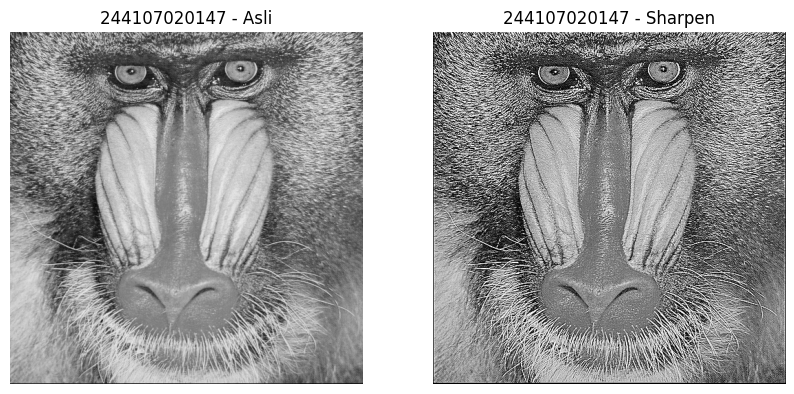

In [7]:
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title(NIM + ' - Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title(NIM + ' - Sharpen')
plt.axis('off')
plt.show()

6. **Buat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter berikut:**

In [8]:
# Average Filter 3x3
kernel_average = (1/9) * np.array([[1,1,1],
                                   [1,1,1],
                                   [1,1,1]])

# Low Pass Filter
kernel_lowpass = (1/16) * np.array([[1,1,1],
                                    [1,4,1],
                                    [1,1,1]])

# High Pass Filter
kernel_highpass = np.array([[-1,0,1],
                            [-1,0,3],
                            [-3,0,1]])

# Sharpen (sudah dipakai sebelumnya)
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

# Emboss
kernel_emboss = np.array([[-2,-1,0],
                          [-1,1,1],
                          [0,1,2]])

# Left Sobel Edge Detection
kernel_sobel_left = np.array([[1,0,-1],
                              [2,0,-2],
                              [1,0,-1]])

# "Canny" kernel (sesuai tabel modul - sebenarnya ini kernel Laplacian sharpening 8-neighbor)
kernel_canny = np.array([[-1,-1,-1],
                         [-1,8,-1],
                         [-1,-1,-1]])

# 21x21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian21 = gaussian_kernel @ gaussian_kernel.transpose()

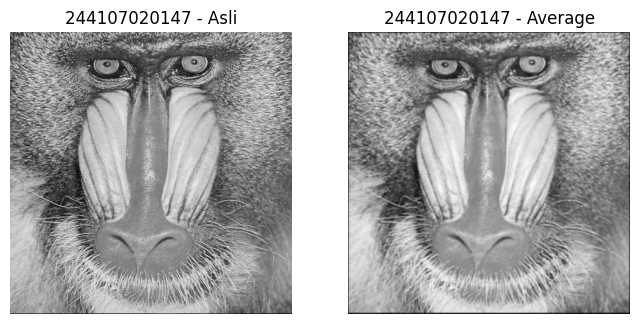

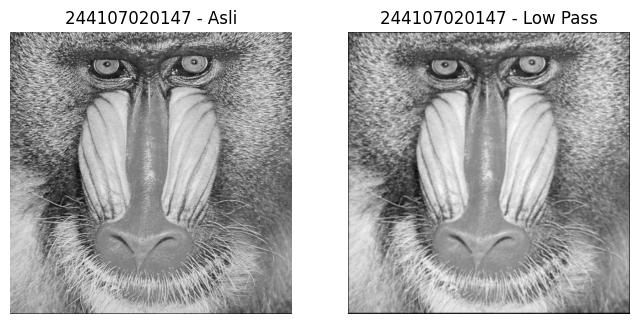

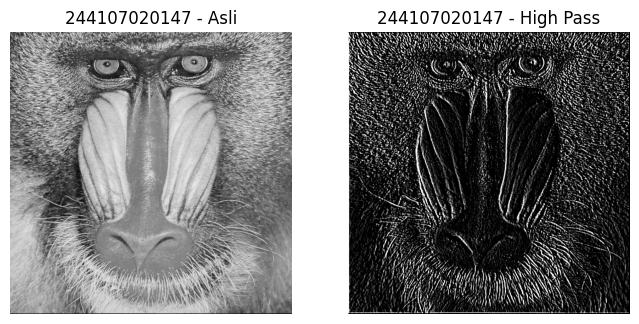

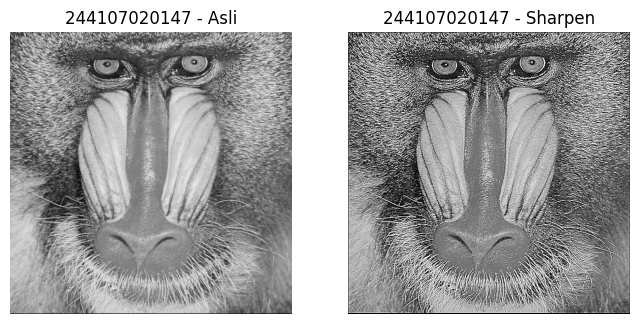

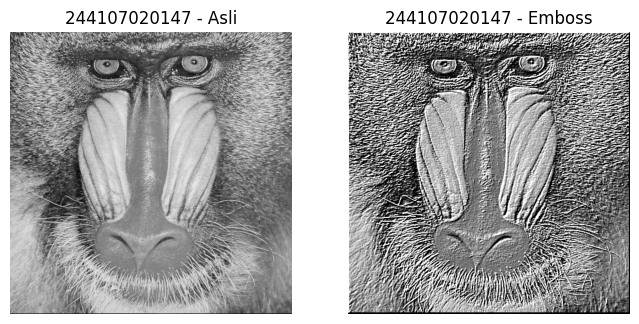

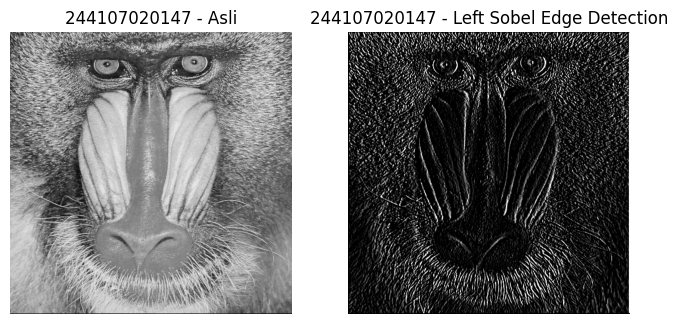

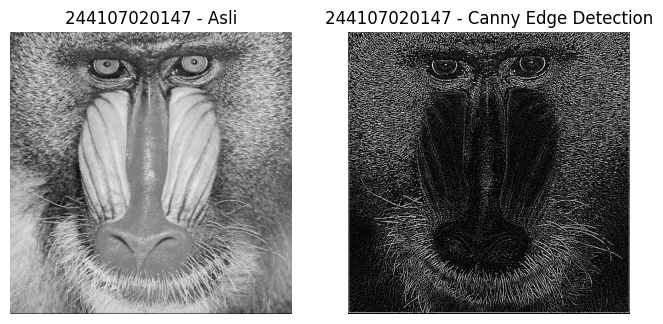

In [11]:
kernels = {
    'Average': kernel_average,
    'Low Pass': kernel_lowpass,
    'High Pass': kernel_highpass,
    'Sharpen': kernel_sharpen,
    'Emboss': kernel_emboss,
    'Left Sobel Edge Detection': kernel_sobel_left,
    'Canny Edge Detection': kernel_canny,
}

for nama, k in kernels.items():
    hasil = convolution2d(img_gray, k, 1, 2)
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img_gray, cmap='gray')
    plt.title(NIM + ' - Asli')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(hasil, cmap='gray')
    plt.title(NIM + ' - ' + nama)
    plt.axis('off')
    plt.show()

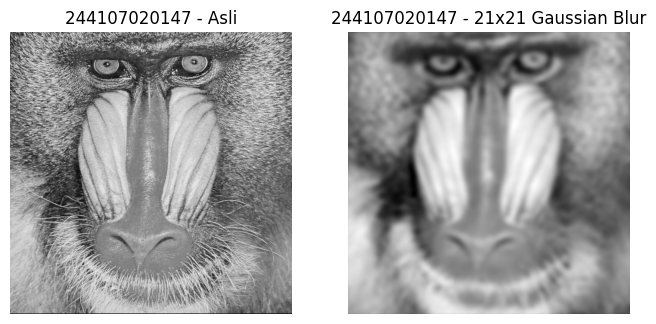

In [10]:
hasil_gaussian = convolution2d(img_gray, kernel_gaussian21, 1, 2)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title(NIM + ' - Asli')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(hasil_gaussian, cmap='gray')
plt.title(NIM + ' - 21x21 Gaussian Blur')
plt.axis('off')
plt.show()

<hr>

### **E. FILTER LIBRARY DAN FILTER MODERN**
**Percobaan 1:**<br>
**Pada percobaan 1 ini, kita akan membuat Filter Gaussian, Sharpen, dan Canny menggunakan library
filter2d dari OpenCV. Filter ini akan kita terapkan pada Image RGB. Pada bagian awal kode terdapat
fungsi show_side_by_side yang digunakan untuk menampilkan gambar secara berdampingan.**

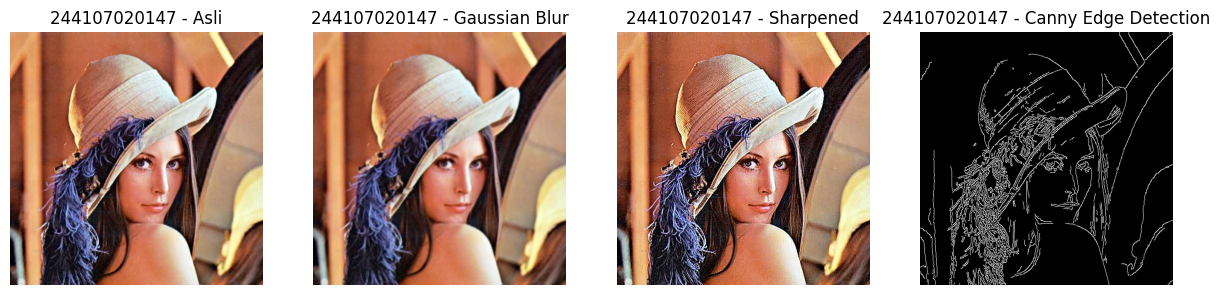

In [12]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread('/content/drive/MyDrive/PCVK2026/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                   [NIM + " - Asli", NIM + " - Gaussian Blur", NIM + " - Sharpened", NIM + " - Canny Edge Detection"])

**Percobaan 2:**<br>
**Pada percobaan 2 berikut ini akan dilakukan filtering modern dari Library OpenCV. Dua filter yang akan
digunakan adalah Bilateral Filtering dan Guided Filter.**


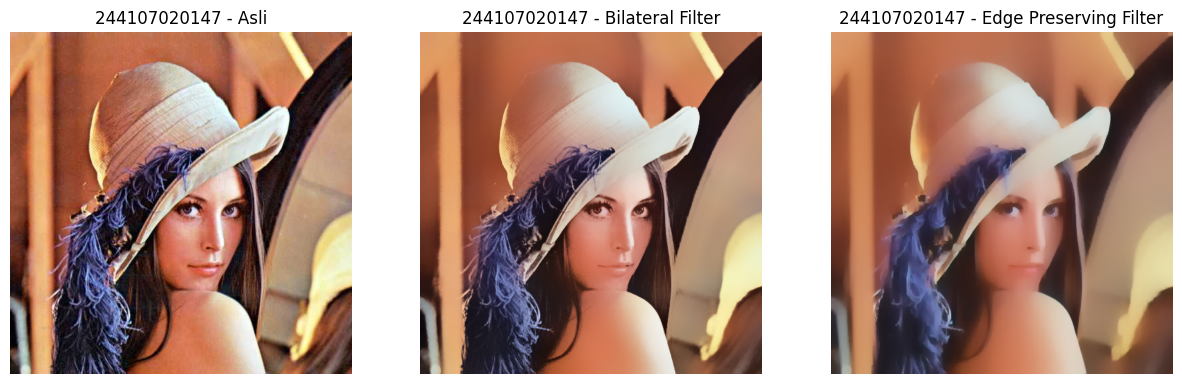

In [14]:
# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                   [NIM + " - Asli", NIM + " - Bilateral Filter", NIM + " - Edge Preserving Filter"])

**Percobaan 3:**<br>
**Percobaan kali ini akan mencoba melihat proses Filtering pada CNN (bagian Feature Map), lakukan
running code beberapa kali dan perhatikan hasil outputnya. Apa yang dapat kamu simpulkan dari hasil
keluaran tersebut.**

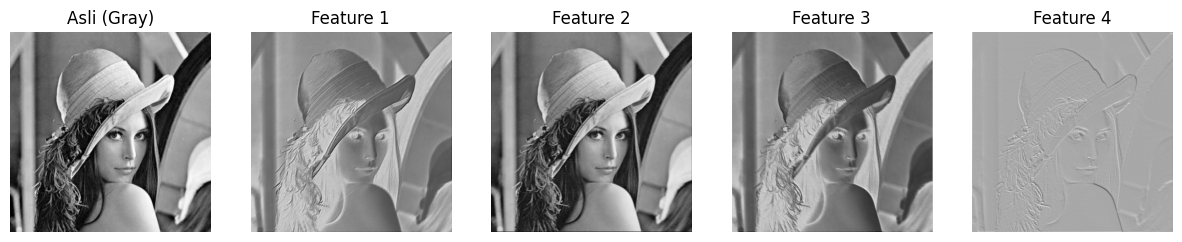

In [17]:
#Filter Feature Map yang digunakan pada CNN, lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

**Kesimpulan:**<br>

Dari beberapa kali running, keempat feature map yang dihasilkan selalu berbeda-beda, baik antar filter dalam satu run maupun antar run yang berbeda. Hal ini terjadi karena bobot kernel pada layer Conv2d diinisialisasi secara acak setiap kali model dibuat, sehingga tiap filter punya nilai koefisien berbeda-beda, ada yang menyerupai efek blur, sharpen, maupun edge detection/emboss. Ini menunjukkan bahwa layer konvolusi CNN bekerja dengan prinsip sama seperti filter spasial konvensional, hanya saja nilai kernelnya dipelajari lewat training, bukan ditentukan manual seperti kernel Sharpen atau Sobel yang sudah dipelajari sebelumnya.

<hr>

**Percobaan 4:**<br>
**Percobaan kali ini akan melakukan efek Beauty dan Vintage yang biasanya digunakan pada Aplikasi
popular saat ini. Filter yang digunakan merupakan kombinasi dari filter tradisional. Perlu diketahui
untuk filter aplikasi popular bisa jadi tidak menggunakan metode yang sama. Pada Aplikasi popular
bisa jadi menggunakan model GenAI dengan data Training untuk memberikan hasil yang lebih akurat.**

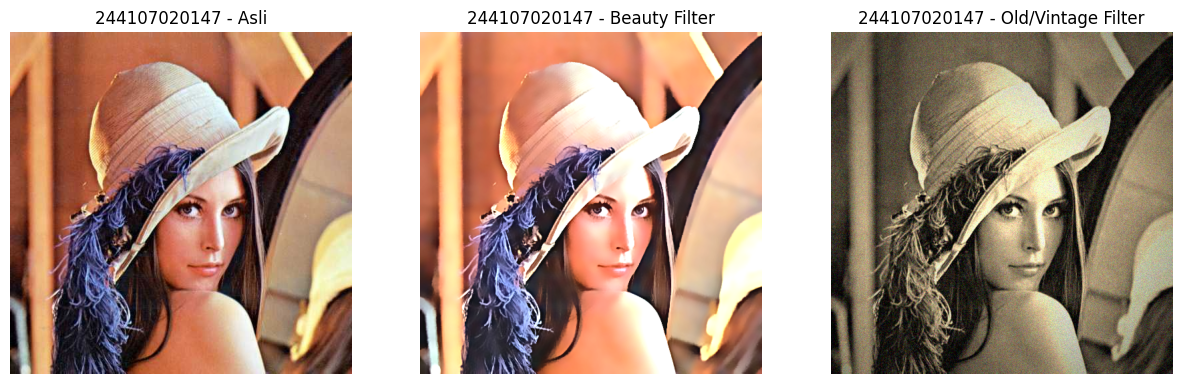

In [18]:
# =====================
# 1. Beauty Filter
# =====================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =====================
# 2. Old/Vintage Filter
# =====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img],
                   [NIM + " - Asli", NIM + " - Beauty Filter", NIM + " - Old/Vintage Filter"])

**Percobaan 5:**<br>
**Percobaan 5 akan menunjukkan pada anda filter anime / cartoon menggunakan kombinasi filter
tradisional.**

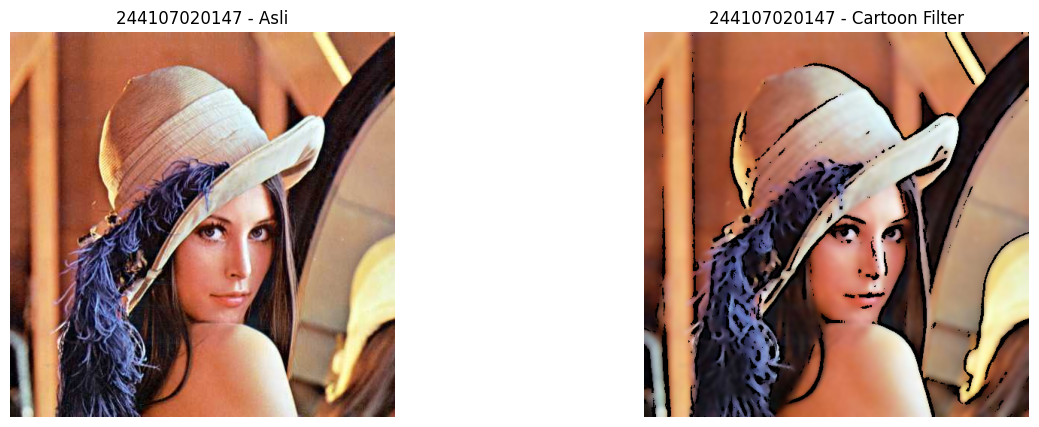

In [19]:
#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                              cv.ADAPTIVE_THRESH_MEAN_C,
                              cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], [NIM + " - Asli", NIM + " - Cartoon Filter"])

**Percobaan 6:**<br>
**Pada Percobaan 6 akan ditunjukkan contoh Filter Malam.**

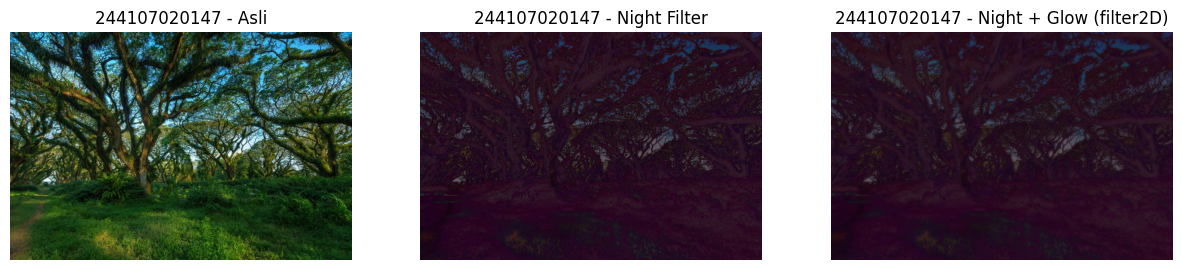

In [20]:
#Night Filter
img = cv.imread('/content/drive/MyDrive/PCVK2026/djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                   [NIM + " - Asli", NIM + " - Night Filter", NIM + " - Night + Glow (filter2D)"])

**Percobaan 7:**<br>
**Percobaan 7 menunjukkan Filter Pagi dan Pagi ditambahkan efek kabut.**

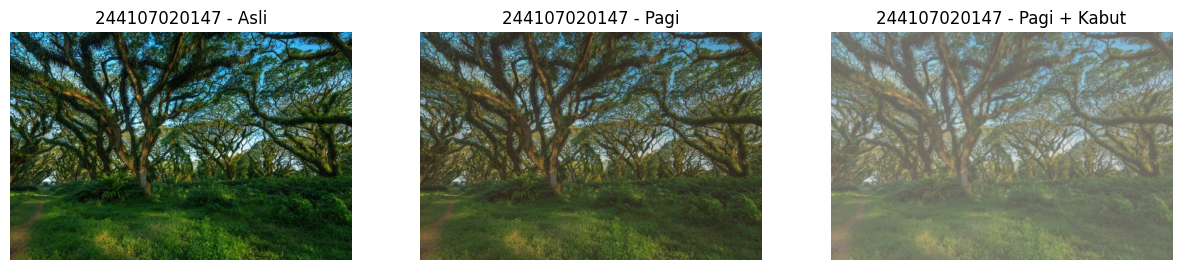

In [21]:
#Filter Suasana pagi dan Kabut
# =========================
# Step 1: Kurangi kontras & cerahkan
# =========================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =========================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                   [NIM + " - Asli", NIM + " - Pagi", NIM + " - Pagi + Kabut"])

<hr>

### **Tugas Praktikum**

1. **Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and
Pepper”** <br>
**a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).**<br>
**b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).**<Br>
**c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus
noise tersebut dibanding Mean Filter.**


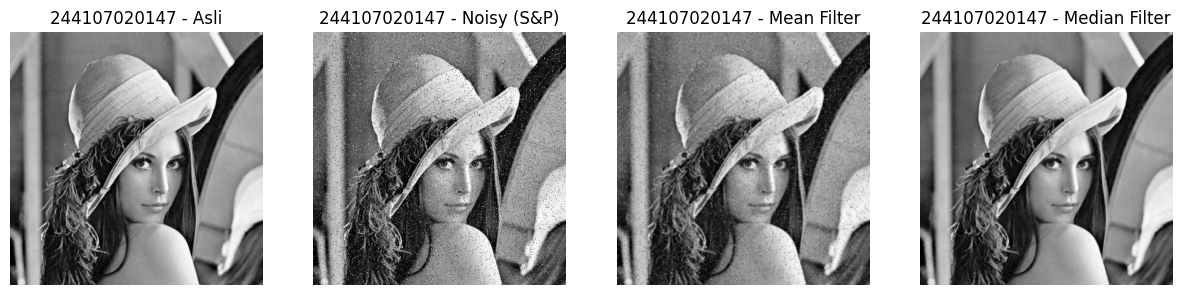

In [29]:
gray = cv.imread('/content/drive/MyDrive/PCVK2026/lena.jpg', cv.IMREAD_GRAYSCALE)

# Tambahkan noise Salt and Pepper
noisy = gray.copy()
prob = 0.05  # probabilitas piksel terkena noise

rnd = np.random.rand(*gray.shape)
noisy[rnd < prob/2] = 0        # pepper (hitam)
noisy[rnd > 1 - prob/2] = 255  # salt (putih)

# Terapkan Mean Filter (3x3)
mean_filtered = cv.blur(noisy, (3,3))

# Terapkan Median Filter (3x3)
median_filtered = cv.medianBlur(noisy, 3)

show_side_by_side([gray, noisy, mean_filtered, median_filtered],
                   [NIM + " - Asli", NIM + " - Noisy (S&P)",
                    NIM + " - Mean Filter", NIM + " - Median Filter"])

**Analisis:**<br>
Median Filter lebih efektif menghilangkan noise salt and pepper dibanding Mean Filter, karena Mean Filter menghitung rata-rata sehingga nilai ekstrem noise (0/255) tetap ikut mempengaruhi hasil dan hanya menyebar jadi blur. Median Filter mengambil nilai tengah, sehingga nilai ekstrem noise otomatis terbuang karena selalu berada di ujung distribusi, bukan di tengah. Hasilnya, Median Filter membersihkan noise secara efektif tanpa membuat citra terlalu buram

<hr>

2. **Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)**<br>
**a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.**<br>
**b. Terapkan pada citra yang sedikit buram (blurry).**<br>
**c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang
dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.**

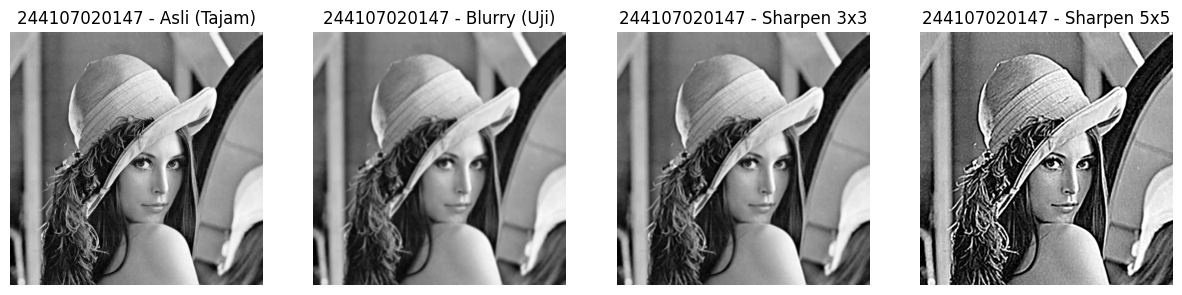

In [30]:
gray = cv.imread('/content/drive/MyDrive/PCVK2026/lena.jpg', cv.IMREAD_GRAYSCALE)

# Buat citra sedikit blur sebagai citra uji (mensimulasikan citra "sedikit buram")
blurry = cv.GaussianBlur(gray, (5,5), 2)

# Kernel Sharpening 3x3 (sesuai modul, Bagian C.3.1)
kernel_3x3 = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])

# Kernel Sharpening 5x5 (prinsip sama: pusat kuat positif, tetangga negatif, total=1)
kernel_5x5 = np.array([[0, 0,-1, 0, 0],
                       [0,-1,-2,-1, 0],
                       [-1,-2,17,-2,-1],
                       [0,-1,-2,-1, 0],
                       [0, 0,-1, 0, 0]])

hasil_3x3 = cv.filter2D(blurry, -1, kernel_3x3)
hasil_5x5 = cv.filter2D(blurry, -1, kernel_5x5)

show_side_by_side([gray, blurry, hasil_3x3, hasil_5x5],
                   [NIM + " - Asli (Tajam)", NIM + " - Blurry (Uji)",
                    NIM + " - Sharpen 3x3", NIM + " - Sharpen 5x5"])

**Analisis:**<br>
Kernel 5×5 menghasilkan tepi yang jauh lebih tajam dibanding kernel 3×3, terlihat dari detail rambut dan tekstur topi yang lebih menonjol. Namun, kernel 5×5 juga memunculkan noise/grain yang lebih terlihat, terutama di area kulit dan background yang seharusnya halus. Kernel 3×3 dipilih sebagai yang paling optimal untuk pemakaian sehari-hari karena sudah cukup menajamkan tepi tanpa noise berlebihan, sedangkan kernel 5×5 lebih cocok untuk citra yang sangat buram dan butuh penajaman ekstra, dengan risiko distorsi noise yang harus diterima.

<hr>

3. **Tugas Kreasi: Filter Kartun Sederhana**<br>
**a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:**
- Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
- Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
- Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.<br><br>
**b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.**

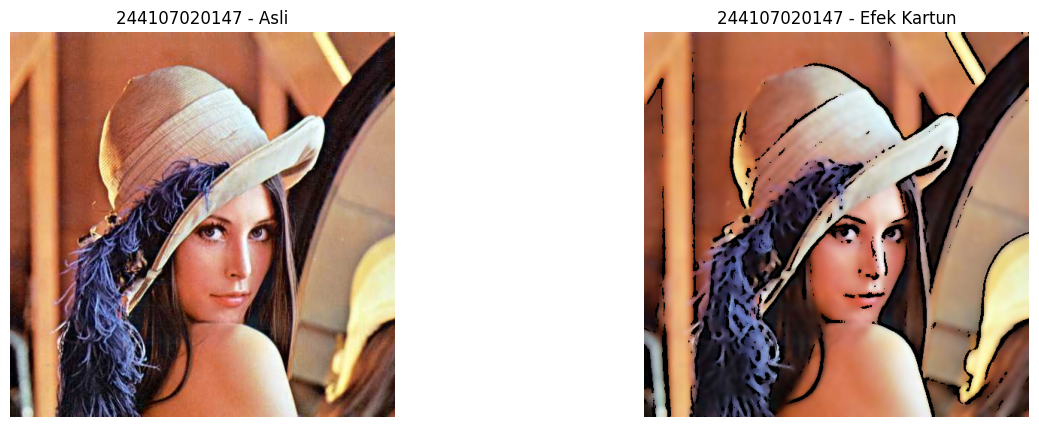

In [31]:
def kartun(image):
    # 1. Penghalusan warna dengan Bilateral Filter
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # 2. Deteksi garis tepi dengan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                  cv.ADAPTIVE_THRESH_MEAN_C,
                                  cv.THRESH_BINARY, 9, 9)

    # 3. Penggabungan menggunakan operasi logika (bitwise_and)
    hasil = cv.bitwise_and(color, color, mask=edges)

    return hasil

img = cv.imread('/content/drive/MyDrive/PCVK2026/lena.jpg')
hasil_kartun = kartun(img)

show_side_by_side([img, hasil_kartun],
                   [NIM + " - Asli", NIM + " - Efek Kartun"])